<a href="https://colab.research.google.com/github/sashavlasits/Data-Science/blob/main/Unit7/SashVlasU7Proj.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install preliz
!pip install bambi

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 513.9/513.9 kB 6.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 171.6/171.6 kB 6.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.8/3.8 MB 34.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.3/62.3 kB 1.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 13.9 MB/s eta 0:00:00
  Attempting uninstall: llvmlite
    Found existing installation: llvmlite 0.43.0
    Uninstalling llvmlite-0.43.0:
      Successfully uninstalled llvmlite-0.43.0
  Attempting uninstall: numba
    Found existing installation: numba 0.60.0
    Uninstalling numba-0.60.0:
      Successfully uninstalled numba-0.60.0
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 109.6/109.6 kB 3.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 218.9/218.9 kB 7.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 54.6/54.6 kB 3.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 259.4/259.

In [2]:
import numpy as np
import pandas as pd
import arviz as az
import matplotlib.pyplot as plt
import preliz as pz
import pymc as pm
import bambi as bmb

In [3]:
import seaborn as sns
import graphviz as gv

#A Semi-Comprehensive Analysis of Taskmaster Causality

###Context

Taskmaster is a semi-popular live British comedy panel show. Five comedians compete in tasks which are often quite silly (think "do the most preposterous thing with this chickpea" or "camoflauge yourself") and are awarded points by the Taskmaster. The show begins with the prize task, in which the points are awarded live and the judgements are subjective. Then three taped tasks are shown and analyzed. These tasks can be objective or subjectively judged, with some being judged based on who was the fastest in completing the task. Finally there is a task performed live on stage that is judged subjectively. They complete tasks for a number of episodes (which vary between series) and a winner is named for each episode as well as at the end. Almost all tasks are judged out of 5, with 5 being the highest and 1 being the lowest. Due to the variance in episode numbers, I will be predicting average points per task instead of total points earned over the series.  

###The Data

I got this data off of a reddit comments section on the Taskmaster subreddit. Based on my knowledge of the show and a brief scan of the spreadsheet, I believe it to be quite accurate. I had to remove many columns of data that I felt to be less than useful or redundant because there were probably 80 columns in the original set. This data set includes mostly data about the points earned on the show, but also has some fun information about the contestants that I thought would be fun to include even though the corrlections don't look great. Because there are so many variables, I isolated just the relevant graphs, ie the ones that include points per task. In terms of data cleaning, I dropped the rows for the upcoming season, dropped the nans values, dropped irrelevant columns, and renamed some of the wordier column names.


In [4]:
tm = pd.read_csv('https://raw.githubusercontent.com/sashavlasits/Data-Science/refs/heads/main/Unit7/Taskmaster%20Contestant%20Ranking%20-%20Series%2021%20-%20Pre%20Series%2021.csv')

In [5]:
tm

,Unnamed: 0,Series,Contestant,Points Per Task,Total Points,Total Tasks,Percentage of Total Points Won,Total Episodes,Total Points In Series,Total Prize Task Points,...,Star sign,First ep of series broadcast date,Age at first show broadcast date,Seat Position,Height in cm,Syllables in name,Number of Times They Said Fuck,Points Scored In Studio,Number of tasks in Studio,Points Per Studio Task
0,1.0,1,Frank Skinner,2.91,93.0,32.0,21.33%,6.0,436.0,21.0,...,Aquarius,28-Jul-2015,58,1,178.0,3,0.0,42.0,14.0,3.00
1,2.0,1,Josh Widdicombe,2.94,94.0,32.0,21.56%,6.0,436.0,18.0,...,Aries,28-Jul-2015,32,2,169.0,4,6.0,44.0,14.0,3.14
2,3.0,1,Roisin Conaty,2.13,68.0,32.0,15.60%,6.0,436.0,10.0,...,Aries,28-Jul-2015,36,3,173.0,5,1.0,30.0,14.0,2.14
3,4.0,1,Romesh Ranganathan,2.91,93.0,32.0,21.33%,6.0,436.0,16.0,...,Aries,28-Jul-2015,37,4,182.0,6,10.0,40.0,14.0,2.86
4,5.0,1,Tim Key,2.75,88.0,32.0,20.18%,6.0,436.0,25.0,...,Virgo,28-Jul-2015,38,5,177.8,2,4.0,44.0,14.0,3.14
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
100,NaN,21,Amy Gledhill,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,Scorpio,1-May-2026,38,1,168.0,4,NaN,NaN,NaN,NaN
101,NaN,21,Armando Iannucci,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,Sagittarius,1-May-2026,62,2,165.0,7,NaN,NaN,NaN,NaN
102,NaN,21,Joanna Page,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,Aries,1-May-2026,49,3,158.0,4,NaN,NaN,NaN,NaN
103,NaN,21,Joel Dommett,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,Gemini,1-May-2026,40,4,182.0,3,NaN,NaN,NaN,NaN


In [6]:
tm2 = tm.drop([100, 101, 102, 103, 104])

In [7]:
#googled to help clean data
cleantm = tm2.drop(columns=['Unnamed: 0','Series','Points Per Studio Task','Percentage of Total Points Won','Predicted Total Subjective Points In Series','Average Point Total Excluding Prize Tasks','Date of birth','Average Point Total Excluding Live Tasks','Difference Between Subjective and Objective Task Scores','Points Scored In Studio','Number of tasks in Studio','Fastest Wins Task Wins','Total Points','Total Tasks','Total Episodes','First ep of series broadcast date','Subjective Task Points','Percentage of subjective tasks in show','Subjective Tasks','Total Points In Series','Total Prize Task Points','Contestant','Subjective Task Average Score','Objective Task Points','Points from "Fastest Wins" Tasks','Objective Tasks','Fastest Wins Tasks'])
cleantm

,Points Per Task,Prize Task Points Per Ep,% of Points From Prize Tasks,Subjective Points Not Including Prize Tasks,% of Points From Subjective Tasks,Objective Task Average Score,% of points from objective tasks,Points Per Fastest Wins Task,Total Live Task Points,Live Task Points Per Ep,...,Total Episode Wins,Gender,Points Per Subjective Task Per Series,Total Subjective Points in Series,Star sign,Age at first show broadcast date,Seat Position,Height in cm,Syllables in name,Number of Times They Said Fuck
0,2.91,3.50,22.58%,2.80,37.63%,2.76,62.37%,2.57,15.0,2.50,...,2.0,M,2.84,156.0,Aquarius,58,1,178.0,3,0.0
1,2.94,3.00,19.15%,2.60,32.98%,3.00,67.02%,3.00,16.0,2.67,...,2.0,M,2.84,156.0,Aries,32,2,169.0,4,6.0
2,2.13,1.67,14.71%,2.20,30.88%,2.24,69.12%,2.43,14.0,2.33,...,1.0,F,2.84,156.0,Aries,36,3,173.0,5,1.0
3,2.91,2.67,17.20%,3.20,34.41%,2.90,65.59%,2.29,18.0,3.00,...,0.0,M,2.84,156.0,Aries,37,4,182.0,6,10.0
4,2.75,4.17,28.41%,2.40,42.05%,2.43,57.95%,2.14,17.0,2.83,...,1.0,M,2.84,156.0,Virgo,38,5,177.8,2,4.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
95,3.02,3.40,22.52%,3.50,54.97%,2.62,45.03%,3.50,25.0,2.50,...,2.0,F,3.34,401.0,Aquarius,27,1,168.0,5,5.0
96,3.02,4.10,27.15%,2.71,52.32%,2.77,47.68%,3.17,25.0,2.50,...,3.0,F,3.34,401.0,Aquarius,31,2,180.0,4,21.0
97,3.02,2.70,17.88%,3.50,50.33%,2.88,49.67%,2.50,26.0,2.60,...,3.0,M,3.34,401.0,NaN,44,3,176.0,3,9.0
98,2.96,3.20,21.62%,4.07,60.14%,2.27,39.86%,2.33,32.0,3.20,...,1.0,M,3.34,401.0,Virgo,56,4,169.0,3,4.0


In [8]:
cleantm2 = cleantm.dropna()
cleantm2

,Points Per Task,Prize Task Points Per Ep,% of Points From Prize Tasks,Subjective Points Not Including Prize Tasks,% of Points From Subjective Tasks,Objective Task Average Score,% of points from objective tasks,Points Per Fastest Wins Task,Total Live Task Points,Live Task Points Per Ep,...,Total Episode Wins,Gender,Points Per Subjective Task Per Series,Total Subjective Points in Series,Star sign,Age at first show broadcast date,Seat Position,Height in cm,Syllables in name,Number of Times They Said Fuck
0,2.91,3.50,22.58%,2.80,37.63%,2.76,62.37%,2.57,15.0,2.50,...,2.0,M,2.84,156.0,Aquarius,58,1,178.0,3,0.0
1,2.94,3.00,19.15%,2.60,32.98%,3.00,67.02%,3.00,16.0,2.67,...,2.0,M,2.84,156.0,Aries,32,2,169.0,4,6.0
2,2.13,1.67,14.71%,2.20,30.88%,2.24,69.12%,2.43,14.0,2.33,...,1.0,F,2.84,156.0,Aries,36,3,173.0,5,1.0
3,2.91,2.67,17.20%,3.20,34.41%,2.90,65.59%,2.29,18.0,3.00,...,0.0,M,2.84,156.0,Aries,37,4,182.0,6,10.0
4,2.75,4.17,28.41%,2.40,42.05%,2.43,57.95%,2.14,17.0,2.83,...,1.0,M,2.84,156.0,Virgo,38,5,177.8,2,4.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
94,3.08,2.80,18.18%,3.54,48.05%,2.96,51.95%,2.90,34.0,3.40,...,2.0,F,3.15,362.0,Taurus,36,5,173.0,4,19.0
95,3.02,3.40,22.52%,3.50,54.97%,2.62,45.03%,3.50,25.0,2.50,...,2.0,F,3.34,401.0,Aquarius,27,1,168.0,5,5.0
96,3.02,4.10,27.15%,2.71,52.32%,2.77,47.68%,3.17,25.0,2.50,...,3.0,F,3.34,401.0,Aquarius,31,2,180.0,4,21.0
98,2.96,3.20,21.62%,4.07,60.14%,2.27,39.86%,2.33,32.0,3.20,...,1.0,M,3.34,401.0,Virgo,56,4,169.0,3,4.0


In [9]:
cleanesttm = cleantm2.rename(columns={"Points Per Task": "PPT", "Subjective Points Not Including Prize Tasks": "Subjective", "Prize Task Points Per Ep" : "Prize" , "Objective Task Average Score": "Objective", "Points Per Fastest Wins Task" : "Fastest", "Live Task Points Per Ep" : "Live" , "Age at first show broadcast date": "Age", "Height in cm" : "Height", "Syllables in name" : "Syllables", "Number of Times They Said Fuck": "Fs", "Points Per Studio Task": "Studio"})
cleanesttm

,PPT,Prize,% of Points From Prize Tasks,Subjective,% of Points From Subjective Tasks,Objective,% of points from objective tasks,Fastest,Total Live Task Points,Live,...,Total Episode Wins,Gender,Points Per Subjective Task Per Series,Total Subjective Points in Series,Star sign,Age,Seat Position,Height,Syllables,Fs
0,2.91,3.50,22.58%,2.80,37.63%,2.76,62.37%,2.57,15.0,2.50,...,2.0,M,2.84,156.0,Aquarius,58,1,178.0,3,0.0
1,2.94,3.00,19.15%,2.60,32.98%,3.00,67.02%,3.00,16.0,2.67,...,2.0,M,2.84,156.0,Aries,32,2,169.0,4,6.0
2,2.13,1.67,14.71%,2.20,30.88%,2.24,69.12%,2.43,14.0,2.33,...,1.0,F,2.84,156.0,Aries,36,3,173.0,5,1.0
3,2.91,2.67,17.20%,3.20,34.41%,2.90,65.59%,2.29,18.0,3.00,...,0.0,M,2.84,156.0,Aries,37,4,182.0,6,10.0
4,2.75,4.17,28.41%,2.40,42.05%,2.43,57.95%,2.14,17.0,2.83,...,1.0,M,2.84,156.0,Virgo,38,5,177.8,2,4.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
94,3.08,2.80,18.18%,3.54,48.05%,2.96,51.95%,2.90,34.0,3.40,...,2.0,F,3.15,362.0,Taurus,36,5,173.0,4,19.0
95,3.02,3.40,22.52%,3.50,54.97%,2.62,45.03%,3.50,25.0,2.50,...,2.0,F,3.34,401.0,Aquarius,27,1,168.0,5,5.0
96,3.02,4.10,27.15%,2.71,52.32%,2.77,47.68%,3.17,25.0,2.50,...,3.0,F,3.34,401.0,Aquarius,31,2,180.0,4,21.0
98,2.96,3.20,21.62%,4.07,60.14%,2.27,39.86%,2.33,32.0,3.20,...,1.0,M,3.34,401.0,Virgo,56,4,169.0,3,4.0


###The Pair Plot

I'm seeing some very nice correlations in most of these plots that involve objective points data. This makes sense because most of the categories are subsets of total points, but the correllations are still not foregone conclusions. The random contestant trivia doesn't show quite as good correlations, but I still think including it would be fun. Because there are so many variables, I isolated just the relevant graphs, ie the ones that include points per task.

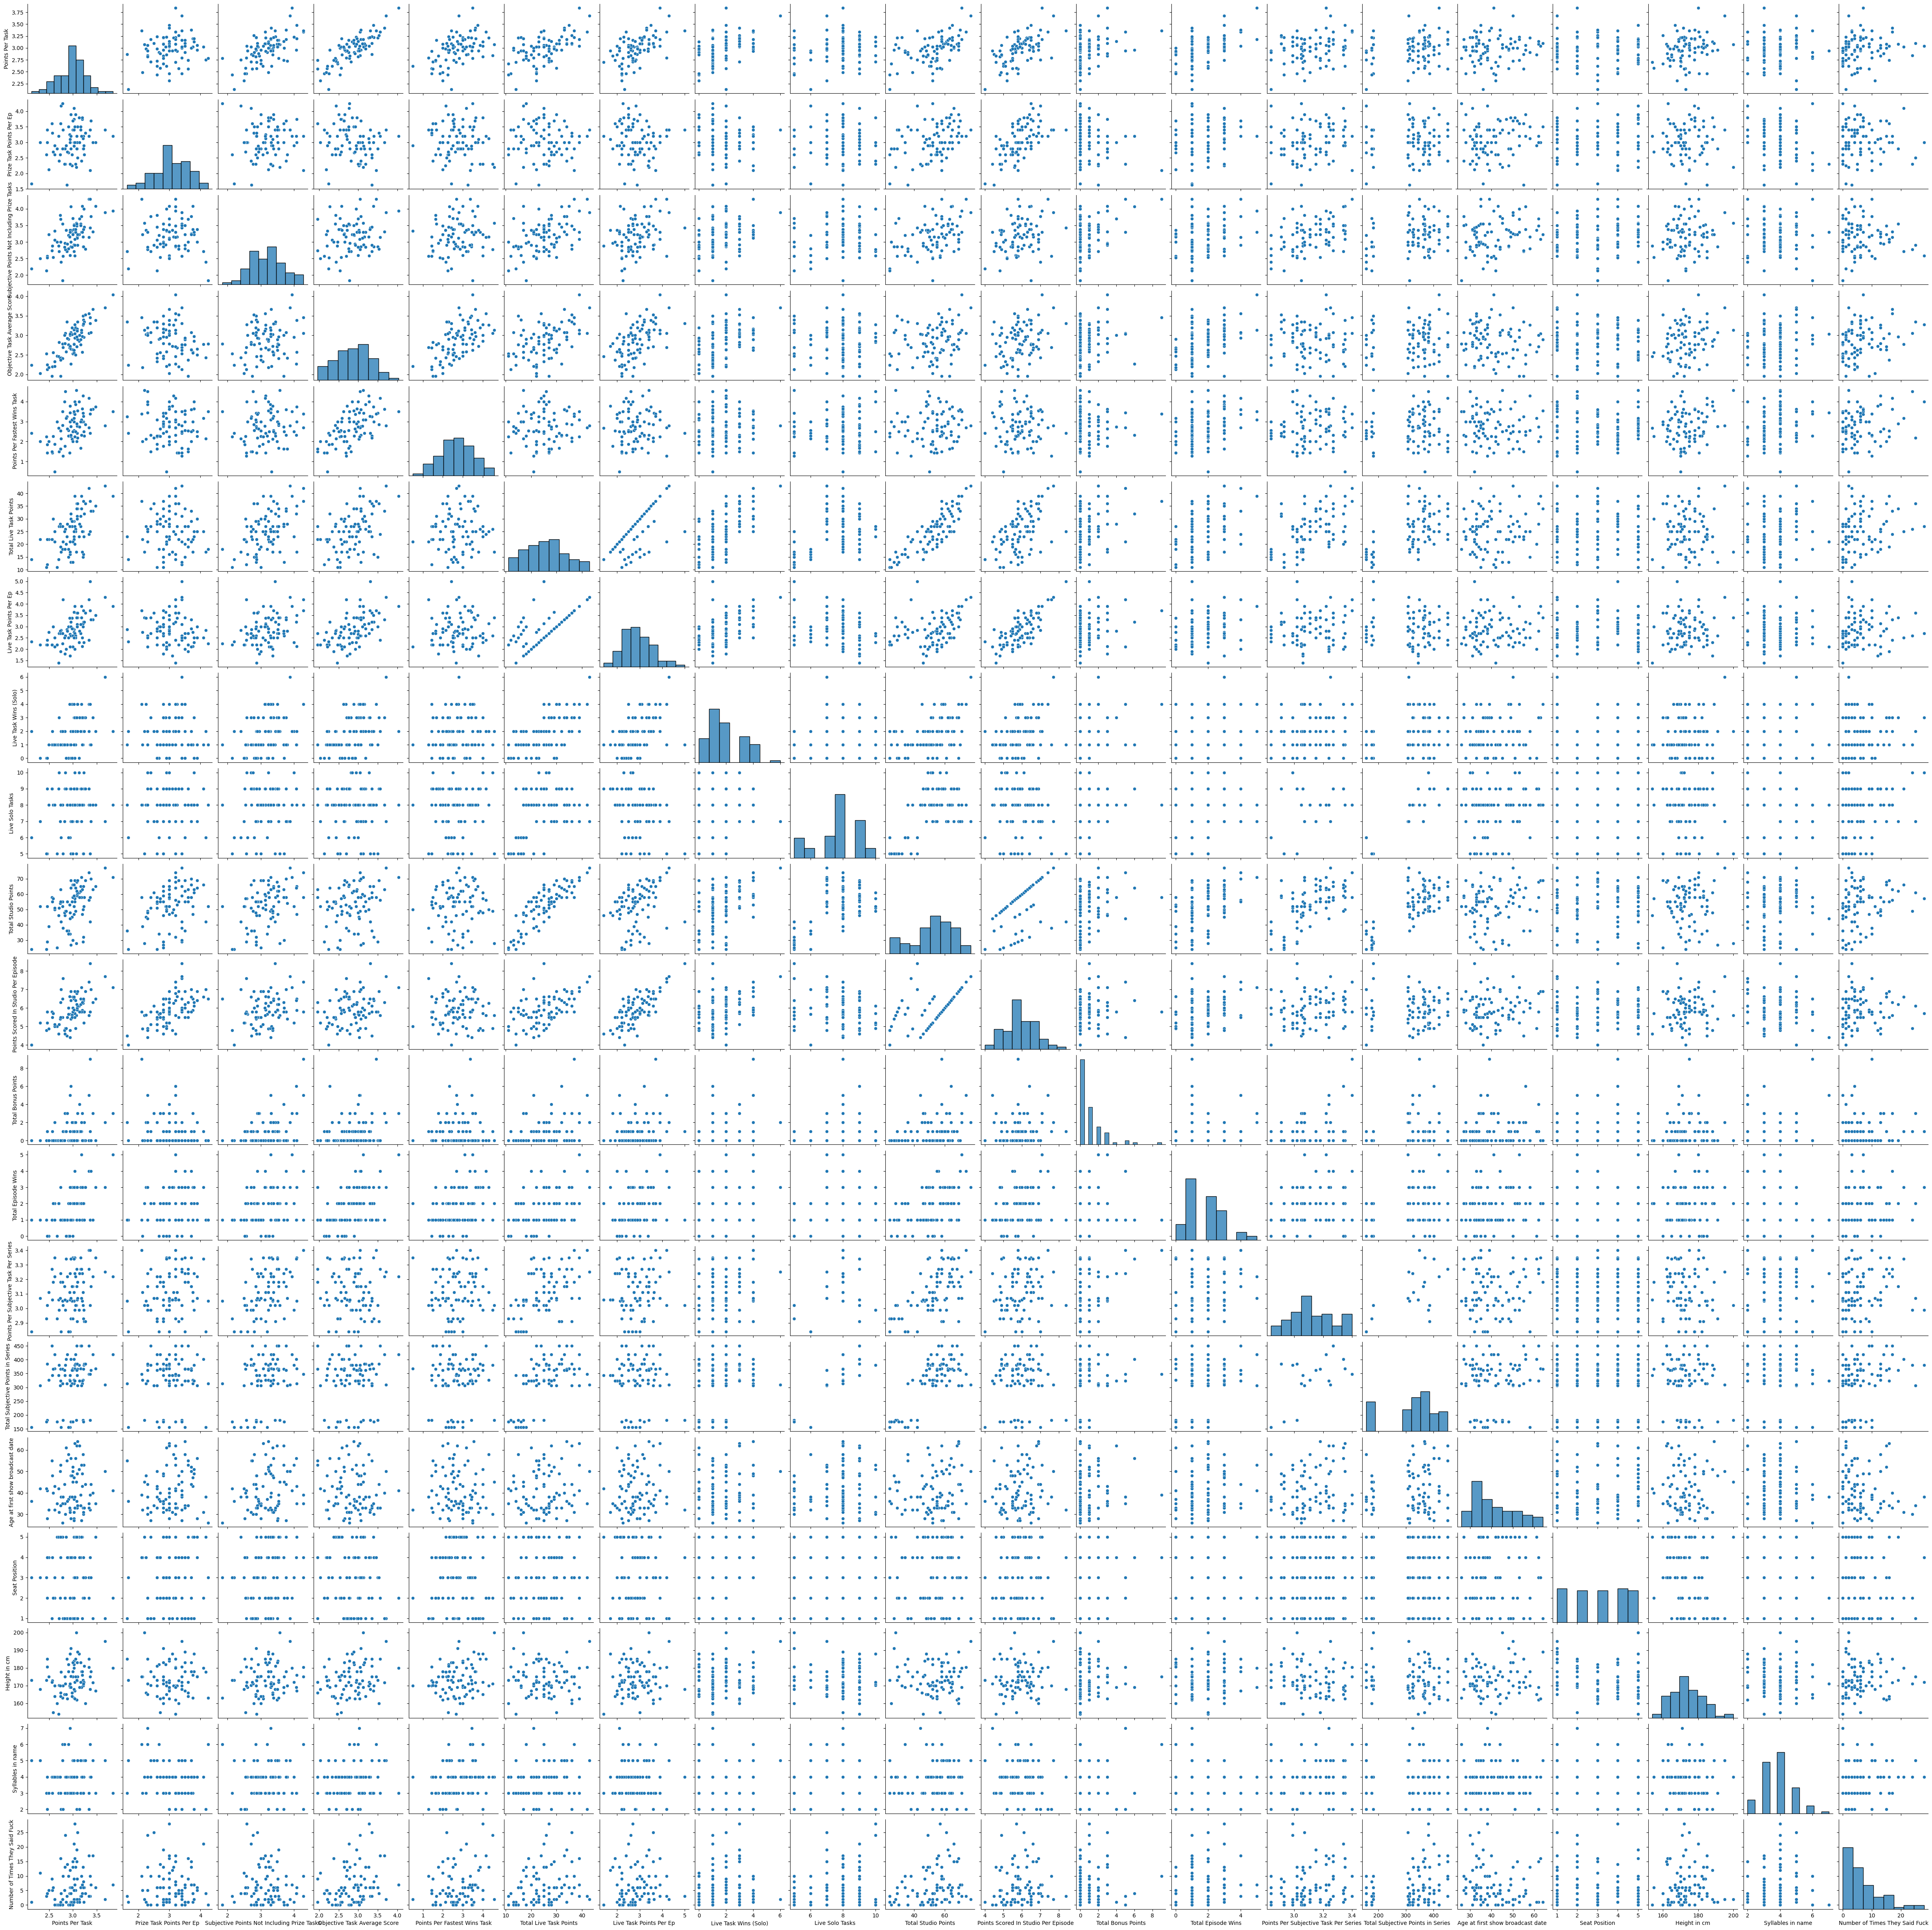

In [ ]:
sns.pairplot(cleanesttm)

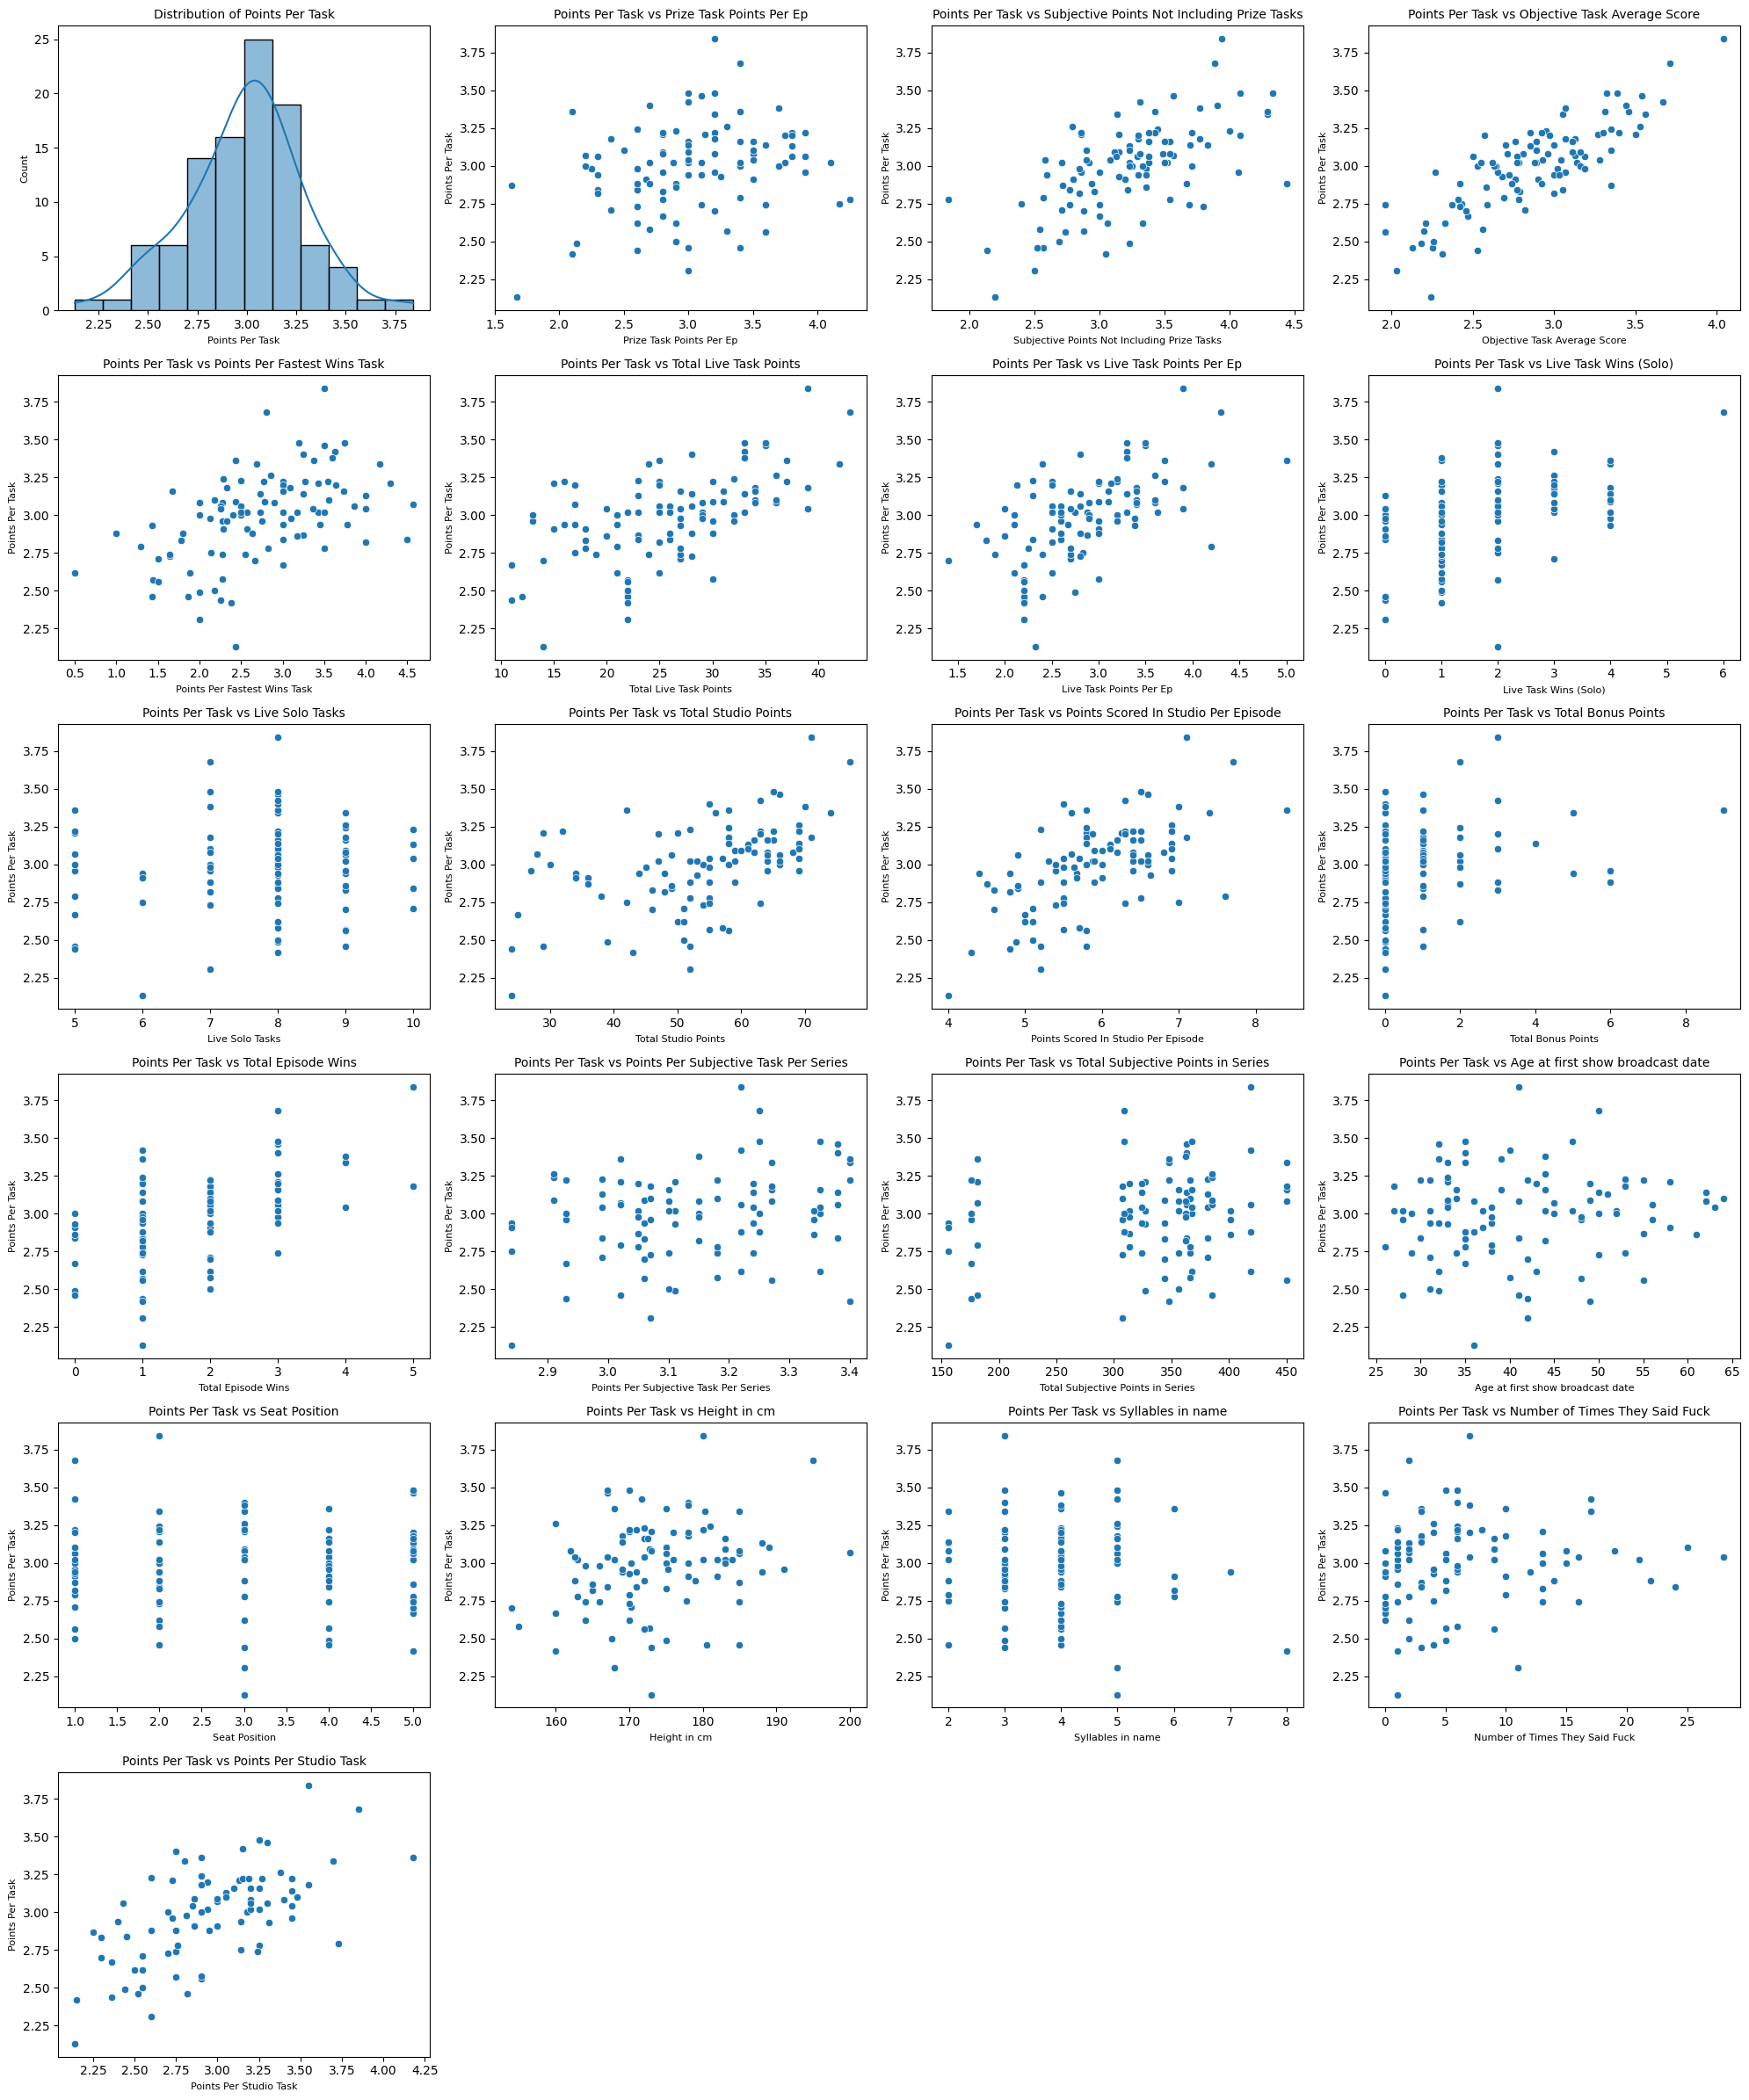

In [ ]:
###I made gemeni do this for me because I was confused

import matplotlib.pyplot as plt
import seaborn as sns
import math

numeric_cols = cleantm.select_dtypes(include=['number']).columns.tolist()

# Choose the variable you want to 'isolate' (e.g., 'Points Per Task')
chosen_variable = 'Points Per Task'

# Remove the chosen variable from the list of other variables for scatter plots
other_numeric_cols = [col for col in numeric_cols if col != chosen_variable]

# Calculate number of plots needed (distribution + scatter plots)
num_plots = len(other_numeric_cols) + 1

# Determine grid dimensions (e.g., 4 columns, dynamic rows)
num_cols = 4
num_rows = math.ceil(num_plots / num_cols)

# Create a figure and a grid of subplots
fig, axes = plt.subplots(num_rows, num_cols, figsize=(num_cols * 5, num_rows * 4))
axes = axes.flatten() # Flatten the 2D array of axes for easy iteration

# Plot the distribution (histogram/KDE) of the chosen variable first
sns.histplot(cleantm[chosen_variable], kde=True, ax=axes[0])
axes[0].set_title(f'Distribution of {chosen_variable}', fontsize=10)
axes[0].set_xlabel(chosen_variable, fontsize=8)
axes[0].set_ylabel('Count', fontsize=8)

# Plot scatter plots of the chosen variable against all other numerical variables
for i, col in enumerate(other_numeric_cols):
    sns.scatterplot(x=cleantm[col], y=cleantm[chosen_variable], ax=axes[i + 1])
    axes[i + 1].set_title(f'{chosen_variable} vs {col}', fontsize=10)
    axes[i + 1].set_xlabel(col, fontsize=8)
    axes[i + 1].set_ylabel(chosen_variable, fontsize=8)

# Hide any unused subplots
for i in range(num_plots, len(axes)):
    fig.delaxes(axes[i])

plt.tight_layout()
plt.show()

###The Causal Diagram

This is an even grosser mess of spaghetti than the last one. There are a lot of connections here because many of the  tasks can fall into multiple categories. As in, a task can be objectively judged and live and fastest wins simoultaneously. Thus, there are many heirarchies that I will have to contend with. In terms of interactions, the main one I see is the one between points per task and episode wins. More episode wins means more episodes with high point totals, and high points per task would likely lead to a contestant winning more episodes.

In [ ]:
dag_b = gv.Digraph(comment='tmclean_dag') #b for bikes

dag_b.node('L', 'live task points per episode')
dag_b.node('U', 'points per subjective task')
dag_b.node('B', 'bonus points')
dag_b.node('O','average objective task points')
dag_b.node('P','points per task')
dag_b.node('E','episode wins')
dag_b.node('F', 'points per fastest wins task')
dag_b.node('R','prize task points per episode')

dag_b.edge('P', 'E', dir='both')

dag_b.edges(['LP','LE','LO','LF','UP','UE','BP','BU','BE','OE','OP','FO','FP','RU','RP','FE','RE'])

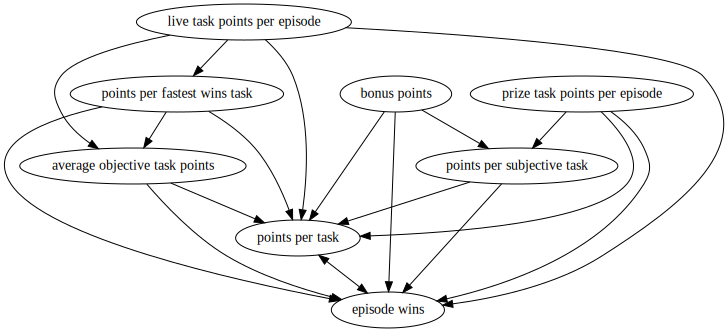

In [ ]:
dag_b

###The Models



1.   All variables no heirarchies
2.   All variables with hierarchies
3.   Just the main categories
4.   Episode Wins
5.   The fun one



#####Model 1:

This will be my base model with all of the points related data categories with no heirarchies or interactions so that I can then successively pair down so I can figure out which factors actually have the most effect. I will also use this model as a base to find the best sort of curve to fit the data adequately. It looks like it does pretty well based on the posterior predictive, but there is definetly room for improvement.

In [14]:
#define the model
model_tm = bmb.Model("`PPT` ~ `Prize` + `Subjective` + `Objective` + `Live` + `Fastest` + `Total Bonus Points` + `Total Episode Wins`", data=cleanesttm)
#fit the model
idata_tm = model_tm.fit(idata_kwargs={'log_likelihood': True})

Output()

<Axes: xlabel='PPT'>

/usr/local/lib/python3.12/dist-packages/IPython/core/events.py:89: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  func(*args, **kwargs)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


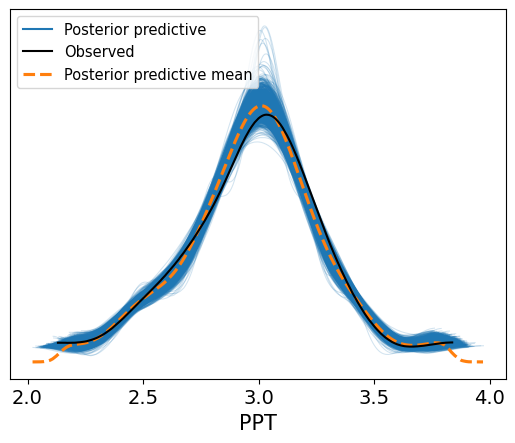

In [ ]:
model_tm.predict(idata_tm, kind="response")
az.plot_ppc(idata_tm)

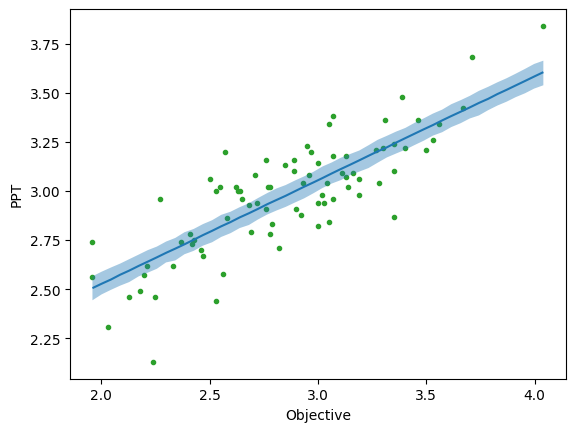

In [30]:
bmb.interpret.plot_predictions(model_tm, idata_tm, "Objective", pps=True, prob=0.94)
plt.plot(cleanesttm.Objective, cleanesttm.PPT, "C2.", zorder=-3)

#####Model 2

This is the model that reflects my causal diagram, so it has approximately one million heirarchies happening but still includes all of the same variables as the previous one. The amount of heirarchies probably explains the proliferation of divergences, but we're just going to go with it. The posterior predictive looks absolutely amazing though.

In [32]:
#define the model
model_tm2 = bmb.Model("`PPT` ~ `Prize` + `Subjective` + `Objective` + `Live` + `Fastest` + `Total Bonus Points` + (`Total Episode Wins`|`Total Bonus Points`) + (`Total Episode Wins`|`Fastest`) + (`Total Episode Wins`|`Objective`) + (`Total Episode Wins`|`Subjective`) + (`Total Episode Wins`|`Live`) + (`Total Episode Wins`|`Prize`) + (`Subjective`|`Prize`) + (`Objective`|`Fastest`) + (`Subjective`|`Total Bonus Points`) + (`Fastest`|`Live`) + (`Objective`|`Live`))", data=cleanesttm)
#fit the model
idata_tm2 = model_tm2.fit(idata_kwargs={'log_likelihood': True})
sample_new_groups = True

Output()

ERROR:pymc.stats.convergence:There were 131 divergences after tuning. Increase `target_accept` or reparameterize.
ERROR:pymc.stats.convergence:The effective sample size per chain is smaller than 100 for some parameters.  A higher number is needed for reliable rhat and ess computation. See https://arxiv.org/abs/1903.08008 for details


<Axes: xlabel='PPT'>

/usr/local/lib/python3.12/dist-packages/IPython/core/events.py:89: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  func(*args, **kwargs)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


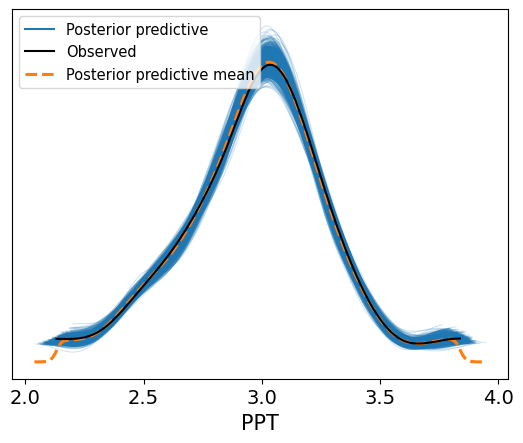

In [ ]:
model_tm2.predict(idata_tm2, kind="response")
az.plot_ppc(idata_tm2)

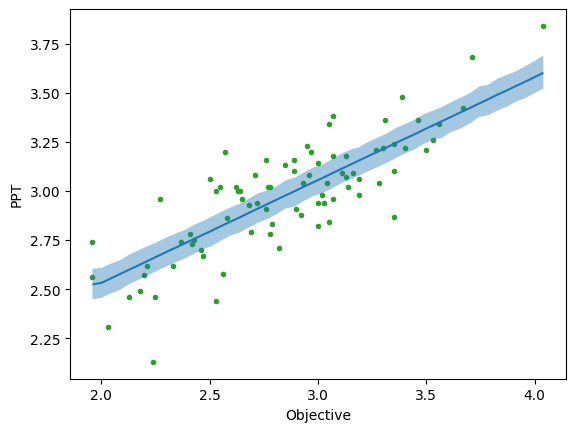

In [38]:
bmb.interpret.plot_predictions(model_tm2, idata_tm2, "Objective", pps=True, prob=0.94, sample_new_groups=True)
plt.plot(cleanesttm.Objective, cleanesttm.PPT, "C2.", zorder=-3)

####Model 3

Now we have to simplify the previous model to see if we can get the same result with a less complicated model. I think that the most clear cut factors affecting point per task are Subjective PPT, Objective PPT, Live PPT, and Studio PPT, since these are the categories that make up the parts of the episode where points are awarded. So I'm just going to include those variables and the applicable heirarchies. This one looks pretty similar to the first model with no heirarchies whatsoever, so clearly there's something I'm missing.

In [16]:
#define the model
model_tm3 = bmb.Model("`PPT` ~ `Prize` + `Subjective` + `Objective` + `Live` + (`Subjective`|`Prize`) + (`Objective`|`Live`)", data=cleanesttm)
#fit the model
idata_tm3 = model_tm3.fit(idata_kwargs={'log_likelihood': True})

Output()

ERROR:pymc.stats.convergence:There was 1 divergence after tuning. Increase `target_accept` or reparameterize.


<Axes: xlabel='PPT'>

/usr/local/lib/python3.12/dist-packages/IPython/core/events.py:89: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  func(*args, **kwargs)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


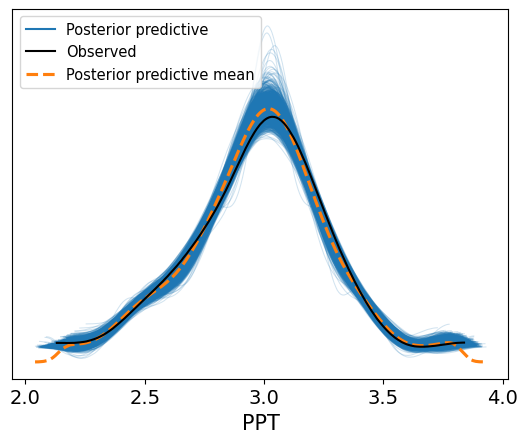

In [ ]:
model_tm3.predict(idata_tm3, kind="response")
az.plot_ppc(idata_tm3)

####Model 4

The previous model not doing as well suggests that the episode wins variable and its corresponding hierarchies is pretty important. This makes sense because people who win episodes have to get a lot of points. I will do this one with just subjective and objective points because those categories encompass most tasks on the show. This one looks quite interesting. There's a lot more variance in the posterior predictive lines, but their average seems to be about the same as the previous models.  

In [17]:
#define the model
model_tm4 = bmb.Model("`PPT` ~ `Subjective` + `Objective` + `Total Episode Wins` + (`Total Episode Wins`|`Objective`) + (`Total Episode Wins`|`Subjective`))", data=cleanesttm)
#fit the model
idata_tm4 = model_tm4.fit(idata_kwargs={'log_likelihood': True})

Output()

ERROR:pymc.stats.convergence:There were 5 divergences after tuning. Increase `target_accept` or reparameterize.
ERROR:pymc.stats.convergence:The effective sample size per chain is smaller than 100 for some parameters.  A higher number is needed for reliable rhat and ess computation. See https://arxiv.org/abs/1903.08008 for details


<Axes: xlabel='PPT'>

/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


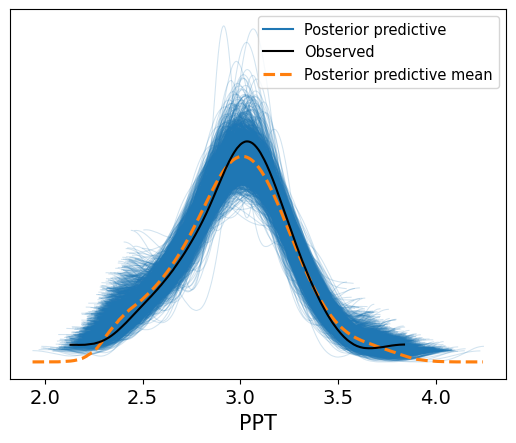

In [ ]:
model_tm4.predict(idata_tm4, kind="response")
az.plot_ppc(idata_tm4)

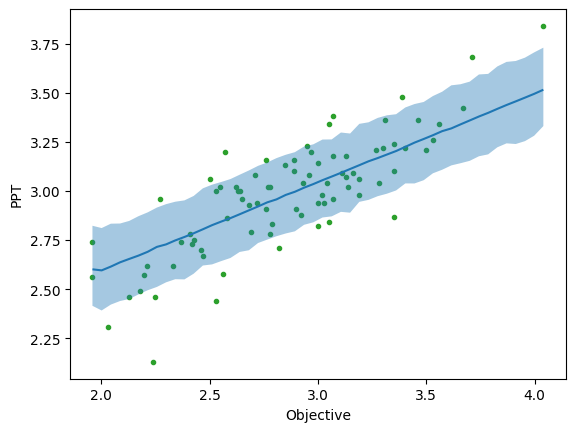

In [44]:
bmb.interpret.plot_predictions(model_tm4, idata_tm4, "Objective", pps=True, prob=0.94, sample_new_groups=True)
plt.plot(cleanesttm.Objective, cleanesttm.PPT, "C2.", zorder=-3)

####Model 5

This is the fun one! I'm just going to throw in all of the fun variables from the data set and see how they do at predicting. I've got contestent height, syllables in their name, seat position, and number of times they dropped an F bomb throughout the series. The 5 contestents are seated in alphabetical order in a row of chairs, so seat position goes from 1 to 5. I don't think there are any heirarchies or interactions going on here, so it's a pretty simple model. Surprising no one, this one performed pretty terribly. Honetly not as bad as I was expecting though, so that's heartening.

In [47]:
#define the model
model_tm5 = bmb.Model("`PPT` ~ `Height` + `Syllables` + `Fs` + `Seat Position`)", data=cleanesttm, family = "t")
#fit the model
idata_tm5 = model_tm5.fit(idata_kwargs={'log_likelihood': True})

Output()

<Axes: xlabel='PPT'>

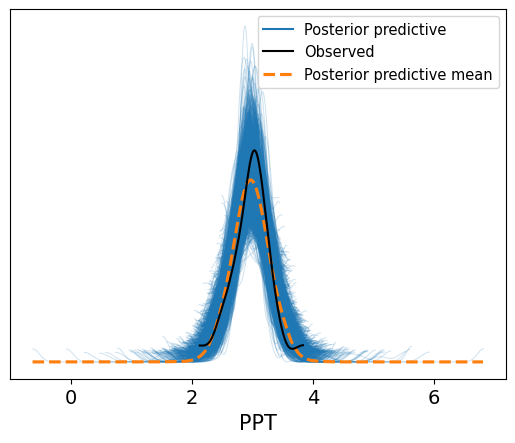

In [48]:
model_tm5.predict(idata_tm5, kind="response")
az.plot_ppc(idata_tm5)

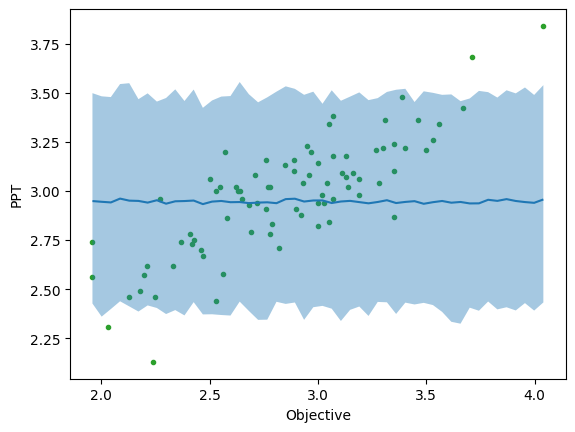

In [49]:
bmb.interpret.plot_predictions(model_tm5, idata_tm5, "Objective", pps=True, prob=0.94, sample_new_groups=True)
plt.plot(cleanesttm.Objective, cleanesttm.PPT, "C2.", zorder=-3)

####Model 6
This is another fun model. I decided to just isolate seat position in this one. In this case I'm basically using it as a proxy for how early in the alphabet each contestent's name is. Weirdly it's actually not an awful model, which maybe suggest that there's a relationship between a contestent's performance on the show and their seat position.

In [50]:
#define the model
model_tm6 = bmb.Model("`PPT` ~ `Seat Position`)", data=cleanesttm, family = "t")
#fit the model
idata_tm6 = model_tm6.fit(idata_kwargs={'log_likelihood': True})

Output()

<Axes: xlabel='PPT'>

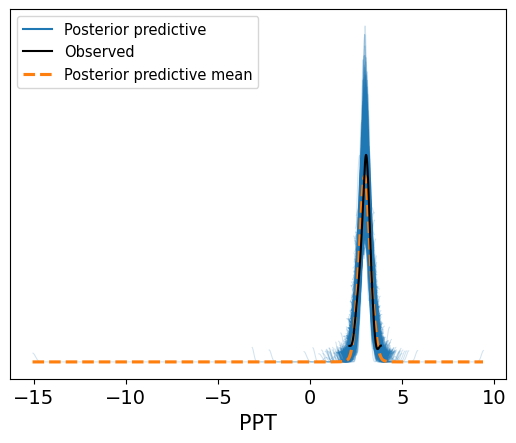

In [51]:
model_tm6.predict(idata_tm6, kind="response")
az.plot_ppc(idata_tm6)

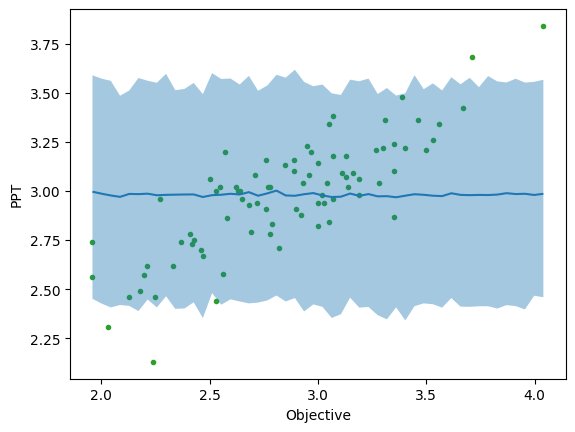

In [52]:
bmb.interpret.plot_predictions(model_tm6, idata_tm6, "Objective", pps=True, prob=0.94, sample_new_groups=True)
plt.plot(cleanesttm.Objective, cleanesttm.PPT, "C2.", zorder=-3)

In [53]:
cmp_df = az.compare( {"all variables no heirarchies":idata_tm,"all variables all heirarchies":idata_tm2, "just main categories":idata_tm3, "episode wins":idata_tm4, "the fun one":idata_tm5, "the fun seat position one":idata_tm6} )

cmp_df

/usr/local/lib/python3.12/dist-packages/arviz/stats/stats.py:797: UserWarning: Estimated shape parameter of Pareto distribution is greater than 0.70 for one or more samples. You should consider using a more robust model, this is because importance sampling is less likely to work well if the marginal posterior and LOO posterior are very different. This is more likely to happen with a non-robust model and highly influential observations.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/arviz/stats/stats.py:797: UserWarning: Estimated shape parameter of Pareto distribution is greater than 0.70 for one or more samples. You should consider using a more robust model, this is because importance sampling is less likely to work well if the marginal posterior and LOO posterior are very different. This is more likely to happen with a non-robust model and highly influential observations.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/arviz/stats/stats.py:797: UserWarning: Estimat

,rank,elpd_loo,p_loo,elpd_diff,weight,se,dse,warning,scale
all variables all heirarchies,0,189.347362,62.882229,0.000000,1.000000e+00,7.158297,0.000000,True,log
just main categories,1,172.185489,19.834413,17.161874,6.591373e-10,8.898070,4.439073,True,log
all variables no heirarchies,2,169.108156,10.117479,20.239206,6.353341e-10,9.658176,5.413405,True,log
episode wins,3,68.429097,27.447269,120.918266,1.487793e-10,5.886136,8.424871,True,log
the fun one,4,-15.713211,5.305929,205.060573,5.782180e-12,7.807545,10.097536,False,log
the fun seat position one,5,-17.577148,3.141655,206.924511,0.000000e+00,7.720491,9.960733,False,log


<Axes: title={'center': 'Model comparison\nhigher is better'}, xlabel='elpd_loo (log)', ylabel='ranked models'>

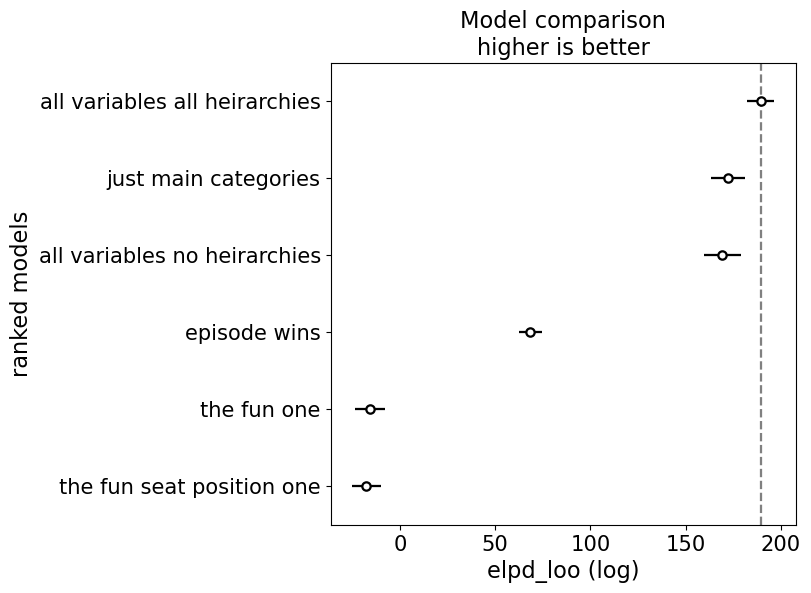

In [54]:
az.plot_compare(cmp_df)

##Conclusion

It seems like the model that goes with my causal diagram predictions is the best model. So it appears that all of the variables that I chose are the quite important in predicting total points. So basically I am just incredibly good at predicting things. This being said, the other models with most of the variables included did pretty well. I think that overall the best model is the one with just the main categories, because it performs almost as well as the one with all of the heirarchies and such, but isn't as complicated and tough to run.